### practical 15

In [157]:
#scala code in WordCount.Scala
# import org.apache.spark.sql.SparkSession

# object WordCount {
#     def main(args: Array[String]):  Unit = {
#         val spark = SparkSession.builder()
#         .appName("Word Count example").master("local[*]").getOrCreate()

#         val sc = spark.sparkContext

#         val data = sc.textFile("input.text")

#         val counts = data 
#             .flatMap(line => line.split(" ")).map(word=> (word,1)).reduceByKey(_+_)

#         counts.collect().foreach(println)
#         spark.stop()
#     }
# }

# run commands:-
# : load WordCount.Scala
# WordCount.main(Array())

### practical 14

In [162]:
import csv 

count= temp = dew = windspeed = 0

with open("Weather_data.txt","r") as file:
    reader = csv.reader(file,delimiter="\t")
    next(reader)

    for row in reader:
        try:
            val_1 = float(row[2])
            val_2 = float(row[3])
            val_3 = float(row[5])
    
            temp+=val_1
            dew += val_2
            windspeed += val_3
            count+=1
        except:
            continue

print(f"Average temperature: {temp/count}")
print(f"Average dew point: {dew/count}")
print(f"Average windspeed: {windspeed/count}")

Average temperature: 14.779704927042093
Average dew point: 60.021829555540236
Average windspeed: 14.997598129281755


### practical 13 & 12

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [24]:
iris = sns.load_dataset('iris')

In [26]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [28]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


array([[<Axes: title={'center': 'sepal_length'}>,
        <Axes: title={'center': 'sepal_width'}>],
       [<Axes: title={'center': 'petal_length'}>,
        <Axes: title={'center': 'petal_width'}>]], dtype=object)

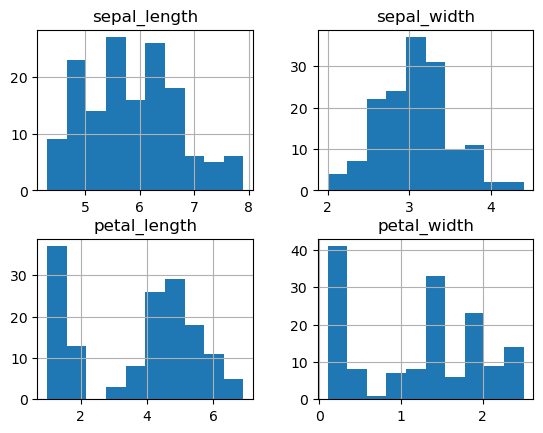

In [36]:
iris.hist()

In [102]:
def scan_outliers(df,col):
    Q1= df[col].quantile(0.25)
    Q3= df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    if len(outliers) == 0:
        return f"No outliers found in '{col}'"
    else:
        return f"Outliers found in {col} :- {outliers[col].values} "

print(scan_outliers(iris, 'sepal_length'))
print(scan_outliers(iris, 'sepal_width'))
print(scan_outliers(iris, 'petal_width'))
print(scan_outliers(iris, 'petal_length'))

No outliers found in 'sepal_length'
Outliers found in sepal_width :- [4.4 4.1 4.2 2. ] 
No outliers found in 'petal_width'
No outliers found in 'petal_length'


In [104]:
def remove_outliers(df,col):
    Q1= df[col].quantile(0.25)
    Q3= df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    removed = df[(df[col] >= lower) | (df[col] <= upper)]
    return removed
    
print(remove_outliers(iris, 'sepal_length'))
print(remove_outliers(iris, 'sepal_width'))
print(remove_outliers(iris, 'petal_width'))
print(remove_outliers(iris, 'petal_length'))

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]
     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1         

In [130]:
import numpy as np
iris_num = iris.select_dtypes(include='number').columns
print(iris_num)
skew_data = []
for iris_data in iris_num:
    skew_data.append(iris[iris_data].skew())
print(skew_data)    

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')
[0.3149109566369728, 0.31896566471359966, -0.27488417975101276, -0.10296674764898116]


Skewness of Marks column: -0.27


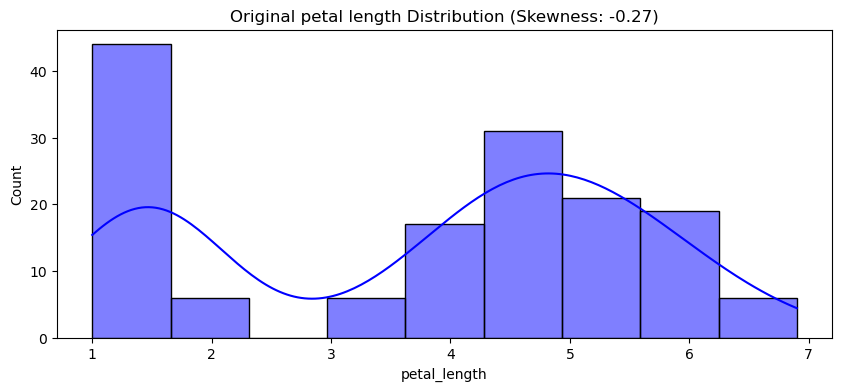

In [138]:
iris_petal_length_skew = skew_data[2]
print(f"Skewness of Marks column: {iris_petal_length_skew:.2f}")


plt.figure(figsize=(10, 4))
sns.histplot(iris['petal_length'], kde=True, color='blue')
plt.title(f"Original petal length Distribution (Skewness: {iris_petal_length_skew:.2f})")
plt.show()

In [150]:
iris['iris_petal_length_Transformed'] = np.cbrt(iris['petal_length'])
transformed_skew = iris['iris_petal_length_Transformed'].skew()
print(f"Skewness after Log Transformation: {transformed_skew:.2f}")

Skewness after Log Transformation: -0.50


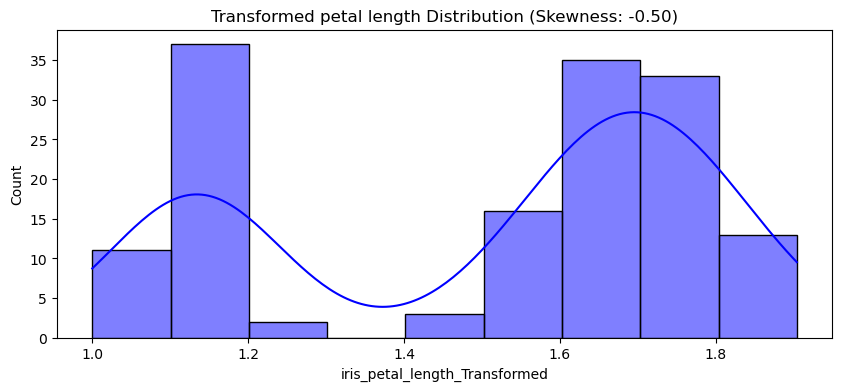

In [152]:
plt.figure(figsize=(10, 4))
sns.histplot(iris['iris_petal_length_Transformed'], kde=True, color='blue')
plt.title(f"Transformed petal length Distribution (Skewness: {transformed_skew :.2f})")
plt.show()

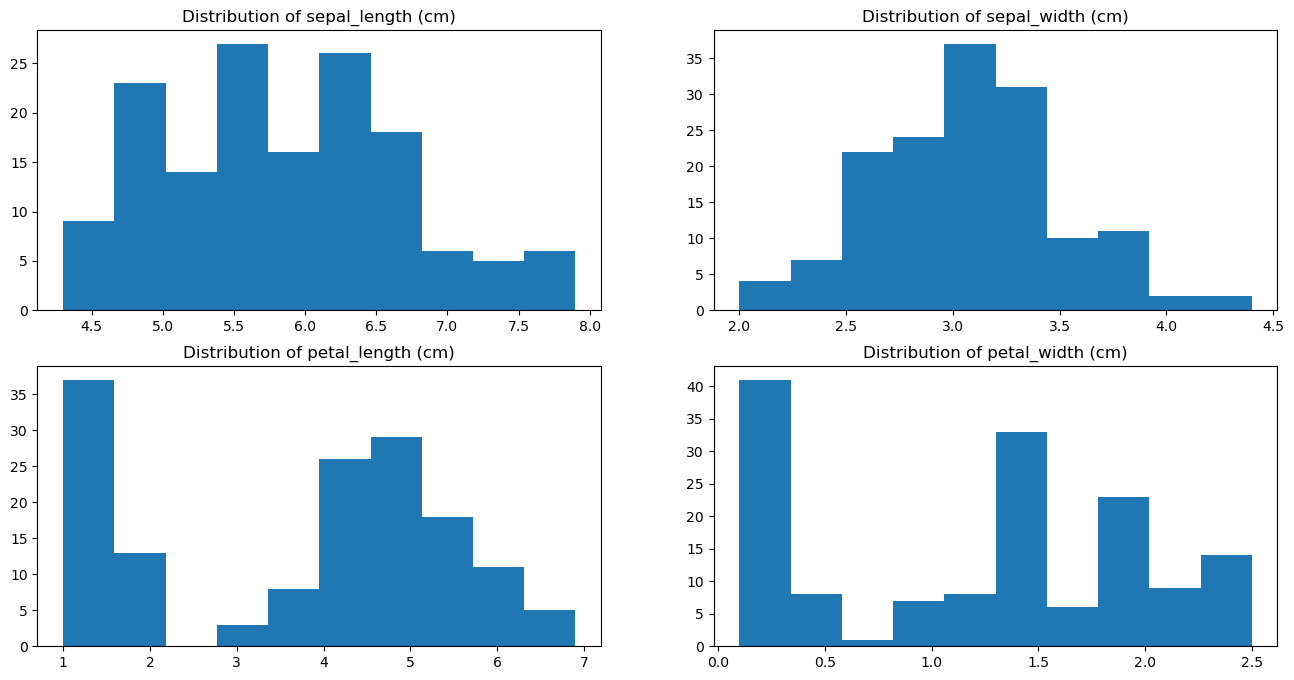

In [48]:
fig,axes = plt.subplots(2,2,figsize=(16,8))
axes[0,0].set_title("Distribution of sepal_length (cm)")
axes[0,0].hist(iris["sepal_length"]);
axes[0,1].set_title("Distribution of sepal_width (cm)")
axes[0,1].hist(iris["sepal_width"]);
axes[1,0].set_title("Distribution of petal_length (cm)")
axes[1,0].hist(iris["petal_length"]);
axes[1,1].set_title("Distribution of petal_width (cm)")
axes[1,1].hist(iris["petal_width"]);


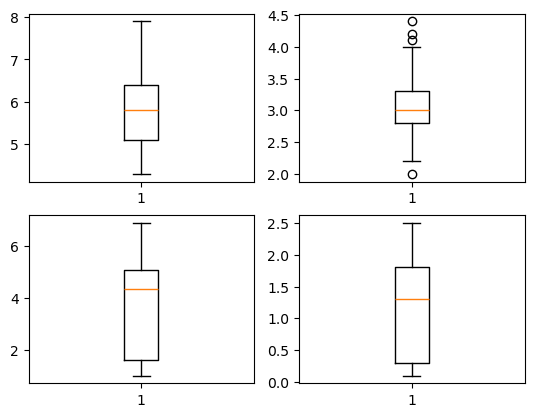

In [52]:
fig = plt.figure(1,figure = (12,8))

ax_1 = fig.add_subplot(221)
ax_2 = fig.add_subplot(222)
ax_3 = fig.add_subplot(223)
ax_4 = fig.add_subplot(224)

bp = ax_1.boxplot(iris["sepal_length"])
bp = ax_2.boxplot(iris["sepal_width"])
bp = ax_3.boxplot(iris["petal_length"])
bp = ax_4.boxplot(iris["petal_width"])

### practical 11

In [174]:
import seaborn as sns
import pandas as pd

df = pd.read_csv("titanic.csv")
df.head()

,Name,PClass,Age,Sex,Survived
0,"Allen, Miss Elisabeth Walton",1st,29.00,female,1
1,"Allison, Miss Helen Loraine",1st,2.00,female,0
2,"Allison, Mr Hudson Joshua Creighton",1st,30.00,male,0
3,"Allison, Mrs Hudson JC (Bessie Waldo Daniels)",1st,25.00,female,0
4,"Allison, Master Hudson Trevor",1st,0.92,male,1


<Axes: xlabel='Sex', ylabel='Age'>

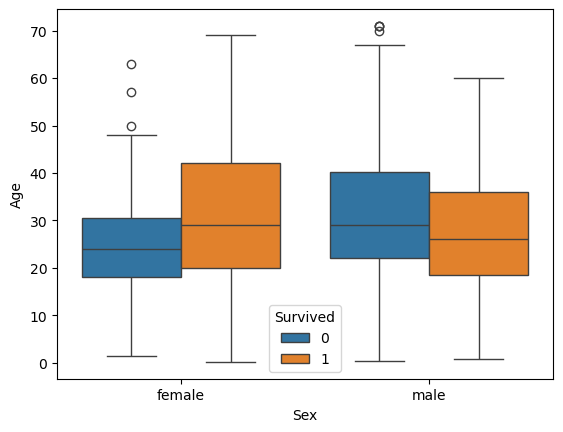

In [182]:
sns.boxplot(x=df["Sex"],y=df["Age"],hue="Survived",data=df)

<Axes: xlabel='Sex', ylabel='Age'>

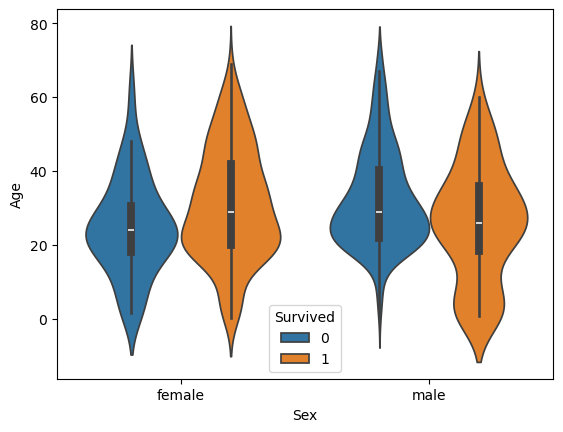

In [184]:
sns.violinplot(x=df["Sex"],y=df["Age"],hue="Survived",data=df)

### practical 10

In [210]:
import seaborn as sns

dataset = sns.load_dataset('titanic')
dataset.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


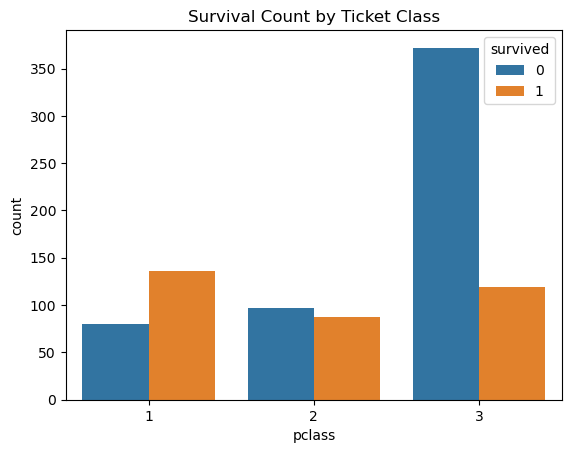

In [208]:
sns.countplot(x='pclass', hue='survived', data=dataset)
plt.title('Survival Count by Ticket Class')
plt.show()

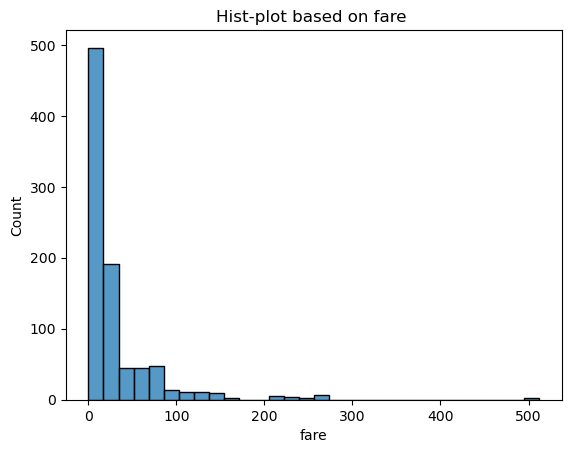

In [214]:
sns.histplot(x='fare',data=dataset,bins=30)
plt.title('Hist-plot based on fare ')
plt.show()

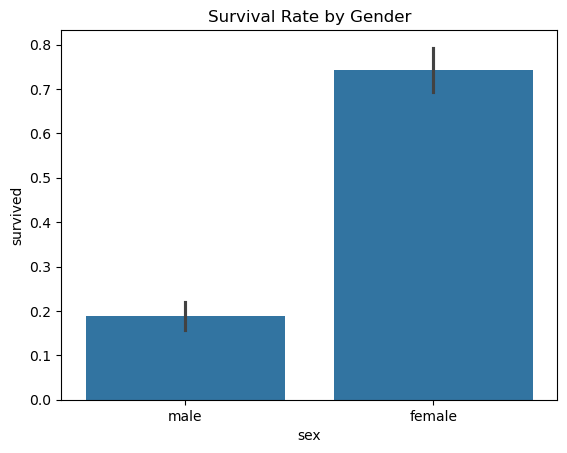

In [216]:
sns.barplot(x='sex', y='survived', data=dataset)
plt.title('Survival Rate by Gender')
plt.show()

C:\Users\YASH\AppData\Local\Temp\ipykernel_18880\2878488585.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['fare'])


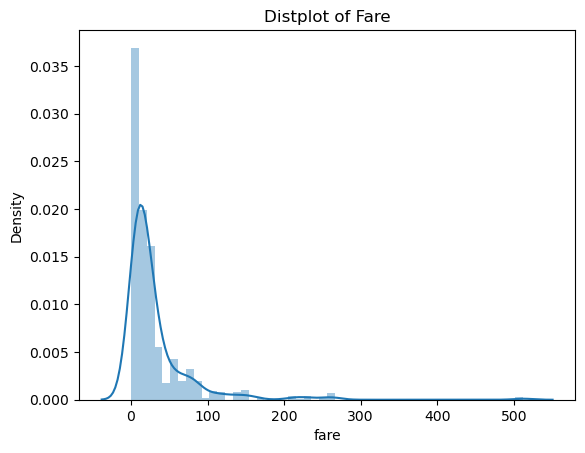

In [218]:
sns.distplot(dataset['fare'])
plt.title('Distplot of Fare')
plt.show()

C:\Users\YASH\AppData\Local\Temp\ipykernel_18880\1527316902.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['fare'],kde=False)


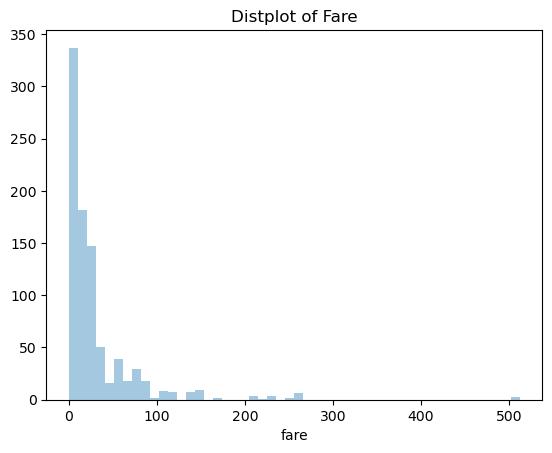

In [220]:
sns.distplot(dataset['fare'],kde=False)
plt.title('Distplot of Fare')
plt.show()

C:\Users\YASH\AppData\Local\Temp\ipykernel_18880\2103124969.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['fare'],hist=False)


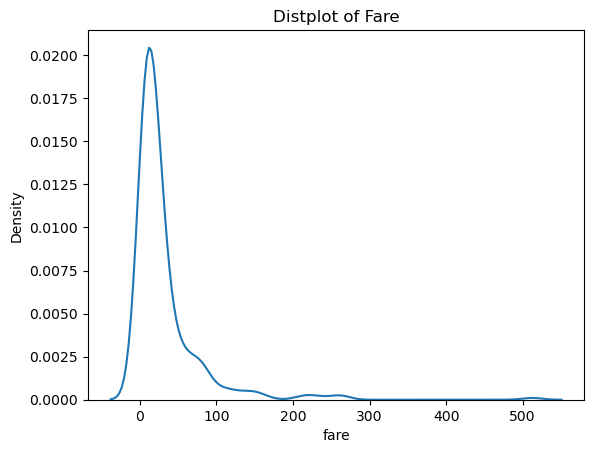

In [222]:
sns.distplot(dataset['fare'],hist=False)
plt.title('Distplot of Fare')
plt.show()

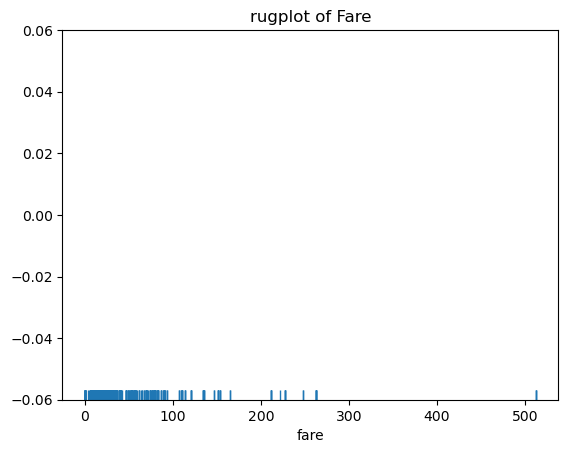

In [224]:
sns.rugplot(dataset['fare'])
plt.title('rugplot of Fare')
plt.show()

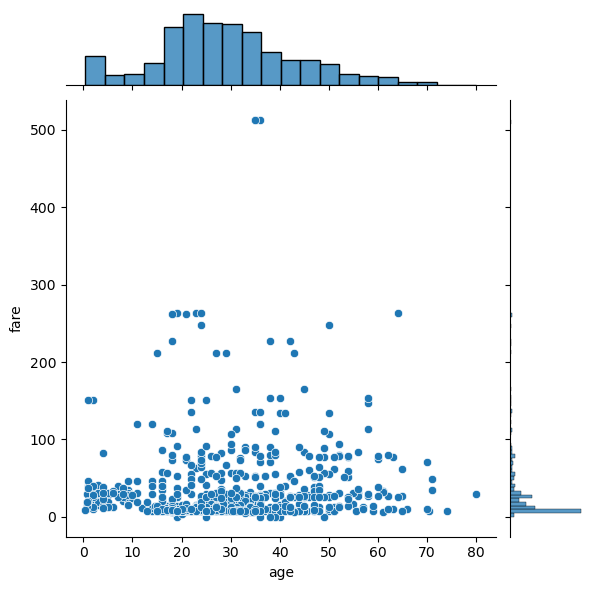

In [230]:
sns.jointplot(x='age',y='fare',data=dataset)

### practical 9

In [237]:
import pandas as pd
import numpy as np
import nltk
import sklearn as sk
import math
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk import pos_tag
nltk.download('averaged_perceptron_tagger')
nltk.download('Stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\YASH\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Error loading Stopwords: Package 'Stopwords' not found in
[nltk_data]     index
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\YASH\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\YASH\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [239]:
# # important things to remember:-
# stop_words = stopwords.words('english')
# stemmer = nltk.PorterStemmer()
# words = ['rain', 'rained', 'raining', 'rains','rainy']
# stemmed = [stemmer.stem(word) for word in words]
# print(stemmed)
# lemmatizer = nltk.WordNetLemmatizer()
# lemmatized = [lemmatizer.lemmatize(word) for word in cleaned_token]
# print(lemmatized)
# tagged = nltk.pos_tag(cleaned_token)
# print(tagged)

# wordDictA = dict.fromkeys(total, 0)
# wordDictB = dict.fromkeys(total, 0)
# for word in first_block:
#     wordDictA[word]+=1
# for word in second_block:
#     wordDictB[word]+=1

# def computeTF(wordDict, doc):
#     tfDict = {}
#     corpusCount = len(doc)
#     for word, count in wordDict.items():
#         tfDict[word] = count/float(corpusCount)
#     return(tfDict)
# #running our sentences through the tf function:
# tfFirst = computeTF(wordDictA, first_block)
# tfSecond = computeTF(wordDictB, second_block)
# tf = pd.DataFrame([tfFirst, tfSecond])
# print(tf)

# def computeIDF(docList):
#     idfDict = {}
#     N = len(docList)
#     idfDict = dict.fromkeys(docList[0].keys(), 0)
#     for word, val in idfDict.items():
#         idfDict[word] = math.log10(N /(float(val) + 1))
#     return(idfDict)

# idfs = computeIDF([wordDictA, wordDictB])
# idfs1 = pd.DataFrame([wordDictA, wordDictB])
# print(idfs1)

# def computeTFIDF(tfBow, idfs):
#     tfidf = {}
#     for word, val in tfBow.items():
#         tfidf[word] = val*idfs[word]
#     return(tfidf)
# #running our two sentences through the IDF:
# idfFirst = computeTFIDF(tfFirst, idfs)
# idfSecond = computeTFIDF(tfSecond, idfs)
# #putting it in a dataframe
# idf= pd.DataFrame([idfFirst, idfSecond])
# print(idf)

### practical 8

In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [246]:
df = pd.read_csv("13Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [252]:
print(df.iloc[:,1:5]) # rwo and column

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0              5.1           3.5            1.4           0.2
1              4.9           3.0            1.4           0.2
2              4.7           3.2            1.3           0.2
3              4.6           3.1            1.5           0.2
4              5.0           3.6            1.4           0.2
..             ...           ...            ...           ...
145            6.7           3.0            5.2           2.3
146            6.3           2.5            5.0           1.9
147            6.5           3.0            5.2           2.0
148            6.2           3.4            5.4           2.3
149            5.9           3.0            5.1           1.8

[150 rows x 4 columns]


In [250]:
x_train,x_test,y_train,y_test = train_test_split(df.iloc[:,1:5],df["species"],test_size=0.2,random_state=0)

In [254]:
from sklearn.naive_bayes import GaussianNB

In [258]:
nvclassifier=GaussianNB()
nvclassifier.fit(x_train,y_train)

GaussianNB()

In [260]:
y_pred = nvclassifier.predict(x_test)
y_pred

array(['Iris-virginica', 'Iris-versicolor', 'Iris-setosa',
       'Iris-virginica', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa', 'Iris-setosa',
       'Iris-virginica', 'Iris-versicolor', 'Iris-setosa', 'Iris-setosa',
       'Iris-virginica', 'Iris-setosa', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa'], dtype='<U15')

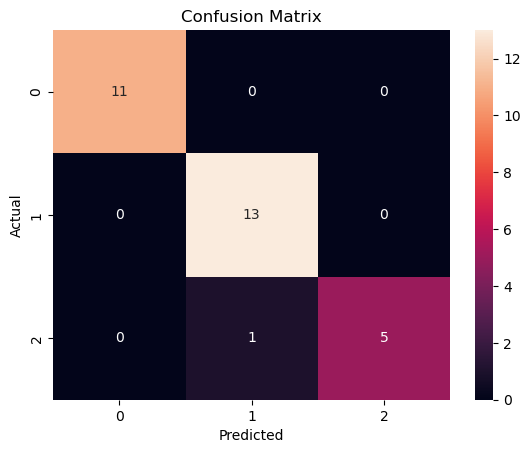

In [264]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### practical 7

In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [271]:
df= pd.read_csv("Social_Network_Ads.csv")
df
df.dtypes

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

In [273]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [275]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [279]:
df_encoded = pd.get_dummies(df,columns = ['Gender'], prefix='is')
df_encoded.drop('User ID', axis = 1, inplace = True)
# df_encoded.head()
x = df_encoded.drop('Purchased',axis = 1)
Y = df_encoded['Purchased']
x_train,x_test,y_train,y_test = train_test_split(x,Y,test_size=0.20,random_state=0)

In [281]:
classifier=LogisticRegression(max_iter=1000)
classifier.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [283]:
y_pred=classifier.predict(x_test)
y_pred


array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1], dtype=int64)

In [285]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred)
cm

array([[56,  2],
       [ 4, 18]], dtype=int64)

In [287]:
tp,fn,fp,tn = confusion_matrix(y_test,y_pred,labels=[1,0]).reshape(-1)
print(tp,fn,fp,tn)

18 4 2 56


In [289]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Accuracy Score:\n",accuracy_score(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))

Accuracy Score:
 0.925
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95        58
           1       0.90      0.82      0.86        22

    accuracy                           0.93        80
   macro avg       0.92      0.89      0.90        80
weighted avg       0.92      0.93      0.92        80



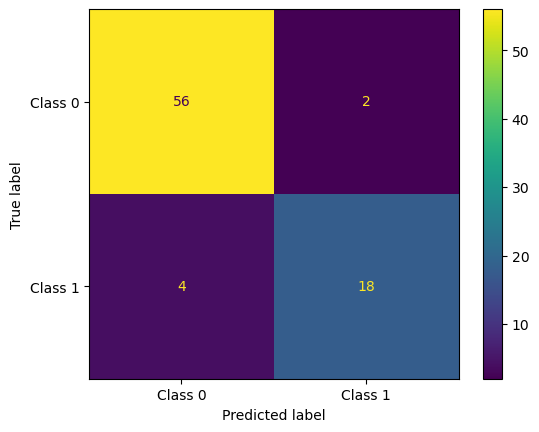

In [291]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot()

### practical 6

In [296]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.datasets import fetch_california_housing
boston = fetch_california_housing()


bos=pd.DataFrame(boston.data,columns=boston.feature_names)
bos['Price']=pd.DataFrame(boston.target)


reg=LinearRegression()
x_train,x_test,y_train,y_test = train_test_split(bos,bos["Price"],test_size=0.2,random_state=10)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

reg.fit(x_train,y_train)

y=reg.predict(x_test)
print(y)

reg.score(x_test,y_test)

from sklearn.metrics import mean_squared_error
y=reg.predict(x_test)
rmse = (np.sqrt(mean_squared_error(y_test,y)))
r2=round(reg.score(x_test,y_test),2)
print(y)
print(rmse)
print(r2)

(16512, 9)
(4128, 9)
(16512,)
(4128,)
[1.674   3.541   1.602   ... 1.313   0.923   5.00001]
[1.674   3.541   1.602   ... 1.313   0.923   5.00001]
3.4822521960061257e-13
1.0


### practical 5 

In [299]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

In [301]:
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [303]:
encoder = OneHotEncoder(sparse_output=False)

encoded_data = encoder.fit_transform(df[['education']])

encoder.get_feature_names_out(['education'])

array(['education_10th', 'education_11th', 'education_12th',
       'education_1st-4th', 'education_5th-6th', 'education_7th-8th',
       'education_9th', 'education_Assoc-acdm', 'education_Assoc-voc',
       'education_Bachelors', 'education_Doctorate', 'education_HS-grad',
       'education_Masters', 'education_Preschool',
       'education_Prof-school', 'education_Some-college'], dtype=object)